In [2]:
import pandas as pd
import seaborn as sns

In [7]:
df= sns.load_dataset("tips")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [10]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [11]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [27]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


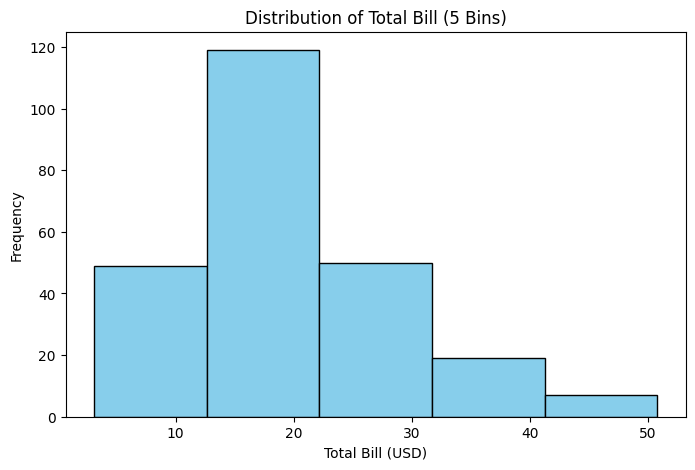

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(df['total_bill'], bins=5, color='skyblue', edgecolor='black')

plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill (5 Bins)")

plt.show()

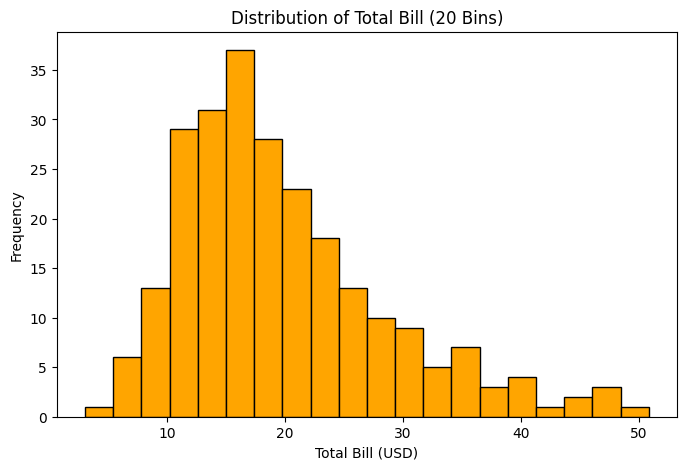

In [29]:
plt.figure(figsize=(8,5))

plt.hist(df['total_bill'], bins=20, color='orange', edgecolor='black')

plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill (20 Bins)")

plt.show()

### Distribution Analysis

The distribution of the `total_bill` variable appears to be **right-skewed (positively skewed)**. Most of the bills are concentrated between lower values (around $10 to $20), while fewer transactions occur at higher bill amounts.

When using **5 bins**, the histogram provides a general overview of the distribution but hides finer details of how the data is spread.

When using **20 bins**, the distribution becomes more detailed, allowing us to observe smaller variations and patterns in the data. However, too many bins can sometimes make the histogram appear noisy.

Therefore, changing the number of bins affects how clearly we can interpret the distribution. Fewer bins simplify the overall pattern, while more bins reveal detailed structure within the data.

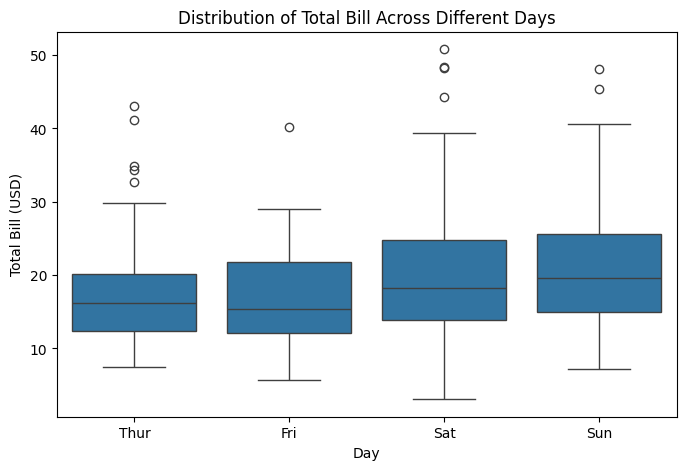

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='day', y='total_bill', data=df)

plt.xlabel("Day")
plt.ylabel("Total Bill (USD)")
plt.title("Distribution of Total Bill Across Different Days")

plt.show()

In [22]:
# calculate quartiles by day
quartiles = df.groupby('day')['total_bill'].quantile([0.25,0.75]).unstack()

quartiles.columns = ['Q1','Q3']

# calculate IQR
quartiles['IQR'] = quartiles['Q3'] - quartiles['Q1']

# calculate lower and upper bounds
quartiles['Lower_Bound'] = quartiles['Q1'] - 1.5 * quartiles['IQR']
quartiles['Upper_Bound'] = quartiles['Q3'] + 1.5 * quartiles['IQR']

quartiles

C:\Users\vemur\AppData\Local\Temp\ipykernel_1640\617099915.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartiles = df.groupby('day')['total_bill'].quantile([0.25,0.75]).unstack()


,Q1,Q3,IQR,Lower_Bound,Upper_Bound
day,,,,,
Thur,12.4425,20.1550,7.7125,0.87375,31.72375
Fri,12.0950,21.7500,9.6550,-2.38750,36.23250
Sat,13.9050,24.7400,10.8350,-2.34750,40.99250
Sun,14.9875,25.5975,10.6100,-0.92750,41.51250


In [30]:
sat = df[df['day'] == 'Sat']

Q1 = sat['total_bill'].quantile(0.25)
Q3 = sat['total_bill'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = sat[(sat['total_bill'] < lower) | (sat['total_bill'] > upper)]

outliers.reset_index()

,index,total_bill,tip,sex,smoker,day,time,size
0,59,48.27,6.73,Male,No,Sat,Dinner,4
1,102,44.30,2.50,Female,Yes,Sat,Dinner,3
2,170,50.81,10.00,Male,Yes,Sat,Dinner,3
3,212,48.33,9.00,Male,No,Sat,Dinner,4


### Outlier Detection Analysis

From the box plot visualization, the **median total bill appears highest on Saturday**, indicating that customers tend to spend more on Saturdays compared to other days.

Outliers can be observed particularly on **Saturday**, where some total bill values are significantly higher than the majority of the data.

To verify this, the Interquartile Range (IQR) was calculated using:

IQR = Q3 − Q1

Outlier boundaries were calculated using the standard rule:

Lower Bound = Q1 − 1.5 × IQR  
Upper Bound = Q3 + 1.5 × IQR

Any values outside these boundaries are considered outliers. The manually calculated outliers matched the points shown in the box plot, confirming the presence of unusually large bills on certain days.

In [26]:
import plotly.express as px

fig = px.scatter(
    df,
    x='total_bill',
    y='tip',
    color='time',
    hover_data=['day','size'],
    title="Relationship Between Total Bill and Tip (Lunch vs Dinner)"
)

fig.show()

### Relationship Between Total Bill and Tip

The scatter plot shows a **positive relationship between total bill and tip**. As the total bill increases, the tip amount generally increases as well. This suggests that customers tend to tip proportionally based on their total bill amount.

When comparing Lunch and Dinner transactions, Dinner appears to have more transactions with higher total bill values and higher tips. Lunch transactions are generally clustered around smaller bill amounts.

The color separation reveals that Dinner transactions dominate the higher spending range, while Lunch transactions occur mostly at lower bill amounts.

One interesting data point observed through hover labels is a transaction with a very high total bill but a relatively small tip compared to other transactions with similar bill values. This point stands out because it deviates from the general tipping pattern.